## Imports


In [1]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import csv
import json
import random
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
from pprint import pprint, pformat

import numpy as np
import jax
import matplotlib.pyplot as plt
from tqdm.auto import trange

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.sampling import Sampling
from pymoo.core.repair import Repair
from pymoo.core.variable import Real, Integer, Binary
from pymoo.core.mixed import MixedVariableMating, MixedVariableDuplicateElimination
from pymoo.algorithms.moo.sms import SMSEMOA
from pymoo.algorithms.moo.nsga2 import NSGA2  # Optional comparison only.
from pymoo.operators.mutation.pm import PM
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize

from LINKS.Optimization import Tools, DifferentiableTools, MechanismRandomizer
from LINKS.Geometry import CurveEngine
from LINKS.Visualization import MechanismVisualizer
from LINKS.CP import REFERENCE_POINTS, MAX_JOINTS, make_empty_submission, evaluate_submission

import pymoo
print("pymoo version:", pymoo.__version__)


pymoo version: 0.6.1


## Settings


In [2]:
# Run this notebook inside the repository containing LINKS, utils, and the .npy files.
TARGET_PATH = Path('kangaroo_target_curves.npy')
# Default: SMS-EMOA -> weighted GD -> SMS-EMOA.
# For a paired comparison, use ALGORITHMS = ("SMS_EMOA", "NSGA2").
ALGORITHMS = ("SMS_EMOA",)
TARGET_INDICES = (2,)              # 0: round; 1: no ears/tail; 2: full kangaroo
QUICK_CHECK = False              # Set False for the longer optimization.
RUN_SWEEP = True                # True compares all joint counts and seeds below.
JOINT_COUNTS = (5,6,7,8,9,10,11,12,13,14,15)  # The randomizer requires at least 5 joints.
SEEDS = (123, 789, 350, 650,)
COORDINATE_BOUNDS = (0.0, 5.0)
DISTANCE_WEIGHTS = (0.50, 0.95)

POPULATION_SIZE = 20 if QUICK_CHECK else 100
GA1_GENERATIONS = 5 if QUICK_CHECK else 500
GD_STEPS = 10 if QUICK_CHECK else 200
GA2_GENERATIONS = 5 if QUICK_CHECK else 200
MAX_GD_CANDIDATES = 4 if QUICK_CHECK else 12
GD_LEARNING_RATE = 4e-4
GD_MAX_BACKTRACKS = 12
GD_MAX_COORDINATE_STEP = 0.02
GD_MIN_IMPROVEMENT = 1e-10
# Mutation settings: real probability, integer probability, per-binary-gene probability.
STAGE1_MUTATION = (0.90, 0.30, 0.02)
STAGE2_MUTATION = (0.3, 0.15, 0.01)
MUTATION_ETA = 20
MAX_SUBMITTED_DESIGNS = 1000
SHOW_FINAL_CURVE = True

RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR = Path('BC_DS_JC_SMS_EMOA_results') / RUN_ID
ACTIVE_JOINT_COUNTS = JOINT_COUNTS if RUN_SWEEP else JOINT_COUNTS[:1]
ACTIVE_SEEDS = SEEDS if RUN_SWEEP else SEEDS[:1]

assert ALGORITHMS and len(set(ALGORITHMS)) == len(ALGORITHMS)
assert set(ALGORITHMS) <= {"SMS_EMOA", "NSGA2"}
assert TARGET_INDICES and JOINT_COUNTS and SEEDS
assert all(0 <= p <= 1 for p in STAGE1_MUTATION + STAGE2_MUTATION)
assert TARGET_PATH.is_file(), 'Open the notebook from the CP1 repository directory.'
assert all(0 <= i < 3 for i in TARGET_INDICES)
assert all(4 <= n <= MAX_JOINTS for n in ACTIVE_JOINT_COUNTS)
assert all(0 < w <= 1 for w in DISTANCE_WEIGHTS)
assert COORDINATE_BOUNDS[0] < COORDINATE_BOUNDS[1]
assert POPULATION_SIZE >= 4 and min(GA1_GENERATIONS, GA2_GENERATIONS, GD_STEPS) >= 1
assert 1 <= MAX_GD_CANDIDATES <= POPULATION_SIZE
assert 1 <= MAX_SUBMITTED_DESIGNS <= 1000
target_curves = np.load(TARGET_PATH)
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print('Mode:', 'quick check' if QUICK_CHECK else 'longer search')
print('Targets:', TARGET_INDICES, '| Joints:', ACTIVE_JOINT_COUNTS, '| Seeds:', ACTIVE_SEEDS)
print('Results:', OUTPUT_DIR)

print("Algorithms:", ALGORITHMS)
print("Each stage allows population size × generation count evaluations; actual counts are recorded.")


Mode: longer search
Targets: (2,) | Joints: (5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15) | Seeds: (123, 789, 350, 650)
Results: BC_DS_JC_SMS_EMOA_results\20261004T220818268388Z
Algorithms: ('SMS_EMOA',)
Each stage allows population size × generation count evaluations; actual counts are recorded.


## Objective tools


In [3]:
# Use the same physical scale and simulation resolution as the final evaluator.
compile_start = perf_counter()
PROBLEM_TOOLS = Tools(timesteps=200, max_size=MAX_JOINTS,
                      material=True, scaled=False, device='cpu')
PROBLEM_TOOLS.compile()
GRADIENT_TOOLS = DifferentiableTools(device='cpu')
GRADIENT_TOOLS.compile()
COMPILE_SECONDS = perf_counter() - compile_start
COUNTS = {'objective_calls': 0, 'gradient_calls': 0}

def objective_values(mech, target_curve):
    COUNTS['objective_calls'] += 1
    d, m = PROBLEM_TOOLS(
        mech['x0'], mech['edges'], mech['fixed_joints'], mech['motor'],
        target_curve, target_idx=mech['target_joint'],
    )
    return np.array([float(np.asarray(d)), float(np.asarray(m))])

def feasible(F, reference):
    return bool(np.all(np.isfinite(F)) and np.all(F >= 0) and np.all(F < reference))

def weighted_loss(F, reference, weight):
    return float(weight * F[0] / reference[0] + (1 - weight) * F[1] / reference[1])

def copy_mechanism(mech):
    return {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in mech.items()}


## Mechanism encoding


In [4]:
class MechanismProblem(ElementwiseProblem):
    def __init__(self, target_curve, n_joints, reference):
        self.N = n_joints
        self.target_curve = target_curve
        self.reference = np.asarray(reference, dtype=float)
        variables = {
            f'C{j}_{i}': Binary()
            for i in range(n_joints) for j in range(i) if (j, i) != (0, 1)
        }
        variables.update({f'X0{i}': Real(bounds=COORDINATE_BOUNDS)
                          for i in range(2 * n_joints)})
        # Motor base 0 is always fixed; crank joint 1 always moves.
        variables.update({f'fixed_nodes{i}': Binary() for i in range(2, n_joints)})
        variables['target'] = Integer(bounds=(1, n_joints - 1))
        super().__init__(vars=variables, n_obj=2, n_ieq_constr=2)

    def decode(self, genes):
        target = int(genes['target'])
        edges = [(0, 1)] + [
            (j, i) for i in range(self.N) for j in range(i)
            if (j, i) != (0, 1) and bool(genes[f'C{j}_{i}'])
        ]
        fixed = [0] + [i for i in range(2, self.N) if bool(genes[f'fixed_nodes{i}'])]
        return dict(
            x0=np.array([genes[f'X0{i}'] for i in range(2 * self.N)], dtype=float).reshape(self.N, 2),
            edges=np.asarray(edges, dtype=int).reshape(-1, 2),
            fixed_joints=np.asarray(fixed, dtype=int), motor=np.array([0, 1]),
            target_joint=target,
        )

    def encode(self, mech):
        x0 = np.asarray(mech['x0'], dtype=float)
        if x0.shape != (self.N, 2):
            raise ValueError('Use a separate problem for each joint count.')
        if not np.array_equal(np.asarray(mech['motor']).ravel(), [0, 1]):
            raise ValueError('This encoding requires motor indices [0, 1].')
        target = mech.get('target_joint')
        if target is None:
            target = mech.get('target_idx')
        target = self.N - 1 if target is None else int(target)
        edge_set = {tuple(sorted(map(int, e))) for e in mech['edges']}
        fixed_set = set(map(int, mech['fixed_joints']))
        if 0 not in fixed_set or 1 in fixed_set or target in fixed_set:
            raise ValueError('Motor base must be fixed; crank and tracing joint must move.')
        genes = {f'C{j}_{i}': (j, i) in edge_set
                 for i in range(self.N) for j in range(i) if (j, i) != (0, 1)}
        genes.update({f'X0{i}': float(v) for i, v in enumerate(x0.ravel())})
        genes.update({f'fixed_nodes{i}': i in fixed_set for i in range(2, self.N)})
        genes['target'] = target
        return genes

    def structurally_valid(self, mech):
        x0, fixed, target = mech['x0'], set(mech['fixed_joints']), mech['target_joint']
        lo, hi = COORDINATE_BOUNDS
        if (not np.all(np.isfinite(x0)) or np.any(x0 < lo) or np.any(x0 > hi)
                or not 1 <= target < self.N or target in fixed):
            return False
        if np.linalg.norm(x0[0] - x0[1]) < 1e-8:
            return False
        # All moving joints must connect to the motor component.
        reached = {0}
        for _ in range(self.N):
            for a, b in mech['edges']:
                if a in reached or b in reached:
                    reached.update((int(a), int(b)))
        return all(i in reached for i in range(self.N) if i not in fixed)

    def _evaluate(self, genes, out, *args, **kwargs):
        mech = self.decode(genes)
        F = objective_values(mech, self.target_curve) if self.structurally_valid(mech) else np.full(2, np.inf)
        # Invalid simulations receive a finite, infeasible penalty for evolutionary selection.
        if not np.all(np.isfinite(F)) or np.any(F < 0):
            F = self.reference * 1e6
        out['F'] = F
        out['G'] = F / self.reference - (1 - 1e-8)


def validate_genes(problem, source):
    genes = dict(source)
    expected, actual = set(problem.vars), set(genes)
    missing, extra = sorted(expected - actual), sorted(actual - expected)
    if missing or extra:
        raise ValueError(
            f'Candidate does not match the {problem.N}-joint problem. '
            f'Missing genes: {missing[:5]}; extra genes: {extra[:5]}. '
            'Restart the kernel and run all cells; never reuse seeds from a different joint count.'
        )
    return genes


class OutputJointRepair(Repair):

    def _do(self, problem, X, **kwargs):
        repaired = []

        for source in X:
            genes = validate_genes(problem, source)

            target = int(
                np.clip(
                    round(genes["target"]),
                    1,
                    problem.N - 1,
                )
            )

            moving = [
                1
            ] + [
                i
                for i in range(2, problem.N)
                if not genes[f"fixed_nodes{i}"]
            ]

            genes["target"] = (
                target
                if target in moving
                else moving[-1]
            )

            repaired.append(genes)

        return np.asarray(repaired, dtype=object)


## Population helpers


In [5]:
def gene_key(problem, genes):
    return tuple(genes[k] for k in problem.vars)

def unique_genes(problem, members):
    found, answer = set(), []
    for genes in members:
        key = gene_key(problem, genes)
        if key not in found:
            found.add(key)
            answer.append(dict(genes))
    return answer

def pareto_indices(F):
    # Two-objective minimization; duplicate objective pairs need only one entry.
    F = np.asarray(F)
    if not len(F):
        return np.array([], dtype=int)
    order = np.lexsort((F[:, 1], F[:, 0]))
    selected, best_material = [], np.inf
    for i in order:
        if F[i, 1] < best_material:
            selected.append(int(i))
            best_material = F[i, 1]
    return np.asarray(selected, dtype=int)

def spread_indices(indices, limit):
    indices = np.asarray(indices, dtype=int)
    if len(indices) <= limit:
        return indices
    return indices[np.linspace(0, len(indices) - 1, limit, dtype=int)]

def evaluate_members(problem, members, require_feasible=False):
    records = []
    for genes in unique_genes(problem, members):
        mech = problem.decode(genes)
        if not problem.structurally_valid(mech):
            continue
        F = objective_values(mech, problem.target_curve)
        if not np.all(np.isfinite(F)) or np.any(F < 0):
            continue
        if require_feasible and not feasible(F, problem.reference):
            continue
        records.append({'genes': genes, 'mech': mech, 'F': F})
    return records

def select_seed_genes(problem, records, limit):
    if not records:
        return []
    F = np.array([r['F'] for r in records])
    cv = np.maximum(F / problem.reference - (1 - 1e-8), 0).sum(axis=1)
    good = np.flatnonzero(cv == 0)
    front = good[pareto_indices(F[good])]
    chosen = list(spread_indices(front, limit))
    # Fill remaining slots with the next feasible tradeoffs, then least violations.
    ranking = np.lexsort((np.sum(F / problem.reference, axis=1), cv))
    selected = set(chosen)
    for i in ranking:
        if len(chosen) >= limit:
            break
        if int(i) not in selected:
            chosen.append(int(i))
            selected.add(int(i))
    return [dict(records[i]['genes']) for i in chosen]

def random_population(problem, seed):
    np.random.seed(seed)
    random.seed(seed)
    generator = MechanismRandomizer(min_size=min(6, problem.N),
                                   max_size=max(14, problem.N), device='cpu')
    members, seen = [], set()
    for _ in trange(20 * POPULATION_SIZE, desc=f'Initialize N={problem.N}', leave=False):
        mech = generator(n=problem.N)
        try:
            genes = problem.encode(mech)
        except ValueError:
            continue
        decoded = problem.decode(genes)
        if not problem.structurally_valid(decoded):
            continue
        F = objective_values(decoded, problem.target_curve)
        key = gene_key(problem, genes)
        if np.all(np.isfinite(F)) and np.all(F >= 0) and key not in seen:
            members.append(genes)
            seen.add(key)
        if len(members) == POPULATION_SIZE:
            break
    if len(members) < POPULATION_SIZE:
        raise RuntimeError(f'Only {len(members)} valid mechanisms found; check bounds and generator output.')
    return members


## Evolutionary search


In [6]:
class SeedSampling(Sampling):
    def __init__(self, members):
        super().__init__()
        self.members = [dict(member) for member in members]

    def _do(self, problem, n_samples, **kwargs):
        if len(self.members) < n_samples:
            raise ValueError('The starting population is too small.')
        return np.asarray([
            validate_genes(problem, member)
            for member in self.members[:n_samples]
        ], dtype=object)


def run_search(problem, members, generations, seed, algorithm_name, stage):
    if stage not in (1, 2):
        raise ValueError('stage must be 1 or 2.')
    settings = STAGE1_MUTATION if stage == 1 else STAGE2_MUTATION
    real_probability, integer_probability, binary_probability = settings
    mutation = {
        Real: PM(prob=real_probability, eta=MUTATION_ETA),
        Integer: PM(prob=integer_probability, eta=MUTATION_ETA,
                    vtype=float, repair=RoundingRepair()),
        Binary: BitflipMutation(prob=1.0, prob_var=binary_probability),
    }
    # Both algorithms use the same mixed-variable variation for a controlled comparison.
    mating = MixedVariableMating(
        mutation=mutation, repair=OutputJointRepair(),
        eliminate_duplicates=MixedVariableDuplicateElimination(),
    )
    algorithms = {'SMS_EMOA': SMSEMOA, 'NSGA2': NSGA2}
    if algorithm_name not in algorithms:
        raise ValueError(f'Unknown algorithm: {algorithm_name}')
    algorithm = algorithms[algorithm_name](
        pop_size=POPULATION_SIZE,
        n_offsprings=POPULATION_SIZE,
        sampling=SeedSampling(members),
        mating=mating,
        repair=OutputJointRepair(),
        eliminate_duplicates=MixedVariableDuplicateElimination(),
    )
    # Native SMS-EMOA survival filters infeasible designs, then uses HV contribution.
    # Use its built-in normalization/reference policy; evaluate_submission remains the score.
    # Match nominal evaluation budgets instead of comparing generation counts alone.
    evaluation_budget = POPULATION_SIZE * generations
    result = minimize(
        problem, algorithm, ('n_eval', evaluation_budget),
        seed=int(seed), verbose=False, save_history=False,
    )
    return ([validate_genes(problem, member) for member in result.pop.get('X')],
            int(result.algorithm.evaluator.n_eval))


## Combined gradient descent


In [7]:
def refine_member(problem, genes, weight):
    current = problem.decode(genes)
    F = objective_values(current, problem.target_curve)
    history = []
    if not feasible(F, problem.reference):
        return dict(genes), history

    for step in range(GD_STEPS):
        COUNTS['gradient_calls'] += 1
        d, m, dg, mg = GRADIENT_TOOLS(
            [current['x0']], [current['edges']], [current['fixed_joints']],
            [current['motor']], problem.target_curve, [current['target_joint']],
        )
        # L = w * distance / distance_limit + (1-w) * material / material_limit.
        gradient = (weight * np.asarray(dg[0]) / problem.reference[0]
                    + (1 - weight) * np.asarray(mg[0]) / problem.reference[1])
        if not np.all(np.isfinite(gradient)):
            break                     # Preserve the last design validated by Tools.
        grad_size = float(np.max(np.abs(gradient)))
        if grad_size < 1e-12:
            break
        rate = min(GD_LEARNING_RATE, GD_MAX_COORDINATE_STEP / grad_size)
        old_loss = weighted_loss(F, problem.reference, weight)
        accepted = False

        for _ in range(GD_MAX_BACKTRACKS + 1):
            trial = copy_mechanism(current)
            trial['x0'] = np.clip(current['x0'] - rate * gradient, *COORDINATE_BOUNDS)
            if problem.structurally_valid(trial):
                trial_F = objective_values(trial, problem.target_curve)
                if feasible(trial_F, problem.reference):
                    trial_loss = weighted_loss(trial_F, problem.reference, weight)
                    if trial_loss < old_loss - GD_MIN_IMPROVEMENT:
                        current, F, accepted = trial, trial_F, True
                        history.append(dict(step=step + 1, weight=weight, loss=trial_loss,
                                            distance=float(F[0]), material=float(F[1]), rate=rate))
                        break
            rate *= 0.5
        if not accepted:
            break
    # Every returned update, including the final one, has passed Tools validation.
    return problem.encode(current), history

def refine_population(problem, members):
    records = evaluate_members(problem, members, require_feasible=True)
    if not records:
        print('No feasible stage-1 candidates: skipping GD; stage 2 will continue searching.')
        return [], []
    F = np.array([r['F'] for r in records])
    chosen = spread_indices(pareto_indices(F), MAX_GD_CANDIDATES)
    refined, logs = [], []
    for index in trange(len(chosen), desc='GD candidates', leave=False):
        record = records[int(chosen[index])]
        for weight in DISTANCE_WEIGHTS:
            # Each weight starts from the same original candidate.
            genes, history = refine_member(problem, record['genes'], weight)
            refined.append(genes)
            logs.append(dict(candidate=index, weight=weight, accepted_steps=len(history),
                             history=history))
    return unique_genes(problem, refined), logs


## Run SMS-EMOA → GD → SMS-EMOA


In [8]:
all_records = {name: {i: [] for i in TARGET_INDICES} for name in ALGORITHMS}
run_summaries = []

for target_index in TARGET_INDICES:
    target_curve = np.asarray(target_curves[target_index])
    reference = np.asarray(REFERENCE_POINTS[target_index], dtype=float)
    for n_joints in ACTIVE_JOINT_COUNTS:
        for seed in ACTIVE_SEEDS:
            problem = MechanismProblem(target_curve, n_joints, reference)
            config_label = f'target_{target_index + 1}_N{n_joints}_seed{seed}'
            init_started = perf_counter()
            init_calls = COUNTS['objective_calls']
            initial = random_population(problem, seed)
            initialization_seconds = perf_counter() - init_started
            initialization_calls = COUNTS['objective_calls'] - init_calls
            np.save(OUTPUT_DIR / f'{config_label}_initial_population.npy',
                    np.asarray(initial, dtype=object))
            # This exact population is reused for every algorithm in this configuration.
            for algorithm_name in ALGORITHMS:
                label = f'{algorithm_name.lower()}_{config_label}'
                print('\nStarting', label)
                before_counts = COUNTS.copy()
                started = perf_counter()
                first, first_evals = run_search(
                    problem, initial, GA1_GENERATIONS, seed, algorithm_name, stage=1,
                )
                first_records = evaluate_members(problem, initial + first, require_feasible=True)
                refined, gd_logs = refine_population(problem, first)

                seed_records = evaluate_members(problem, initial + first + refined)
                second_seeds = select_seed_genes(problem, seed_records, POPULATION_SIZE)
                if len(second_seeds) < POPULATION_SIZE:
                    raise RuntimeError('Too few valid stage-2 seeds; inspect stage 1.')
                second, second_evals = run_search(
                    problem, second_seeds, GA2_GENERATIONS, seed + 1, algorithm_name, stage=2,
                )
                records = evaluate_members(
                    problem, initial + first + refined + second, require_feasible=True,
                )
                all_records[algorithm_name][target_index].extend(records)
                before_distance = min((r['F'][0] for r in first_records), default=np.nan)
                final_best = min(records, key=lambda r: r['F'][0]) if records else None
                # Store a useful bounded collection for this individual experiment.
                F = np.asarray([r['F'] for r in records])
                keep = spread_indices(pareto_indices(F), MAX_SUBMITTED_DESIGNS)
                candidates = [records[int(i)]['mech'] for i in keep]
                np.save(OUTPUT_DIR / f'{label}_candidates.npy',
                        np.asarray(candidates, dtype=object))
                (OUTPUT_DIR / f'{label}_gd.json').write_text(json.dumps(gd_logs, indent=2), encoding='utf-8')
                summary = dict(
                    algorithm=algorithm_name, label=label, target=target_index + 1,
                    joints=n_joints, seed=int(seed), stage2_seed=int(seed + 1),
                    stage1_budget=POPULATION_SIZE * GA1_GENERATIONS,
                    stage2_budget=POPULATION_SIZE * GA2_GENERATIONS,
                    stage1_evaluations=first_evals, stage2_evaluations=second_evals,
                    initialization_calls=initialization_calls,
                    initialization_seconds=initialization_seconds,
                    objective_calls=COUNTS['objective_calls'] - before_counts['objective_calls'],
                    gradient_calls=COUNTS['gradient_calls'] - before_counts['gradient_calls'],
                    gd_accepted_steps=sum(entry['accepted_steps'] for entry in gd_logs),
                    search_seconds=perf_counter() - started,
                    feasible_candidates=len(records), submitted_designs=len(candidates),
                    best_distance_after_stage1=float(before_distance),
                    best_distance=float(final_best['F'][0]) if final_best else np.nan,
                    material_at_best_distance=float(final_best['F'][1]) if final_best else np.nan,
                    links_at_best_distance=len(final_best['mech']['edges']) if final_best else 0,
                )
                run_summaries.append(summary)
                pprint(summary)


Initialize N=5:   0%|          | 0/2000 [00:00<?, ?it/s]


Starting sms_emoa_target_3_N5_seed123


GD candidates:   0%|          | 0/12 [00:00<?, ?it/s]

{'algorithm': 'SMS_EMOA',
 'best_distance': 1.0196762084960938,
 'best_distance_after_stage1': 1.0690014362335205,
 'feasible_candidates': 225,
 'gd_accepted_steps': 1629,
 'gradient_calls': 1647,
 'initialization_calls': 100,
 'initialization_seconds': 16.442145699984394,
 'joints': 5,
 'label': 'sms_emoa_target_3_N5_seed123',
 'links_at_best_distance': 5,
 'material_at_best_distance': 3.794804573059082,
 'objective_calls': 66273,
 'search_seconds': 849.335427700018,
 'seed': 123,
 'stage1_budget': 50000,
 'stage1_evaluations': 50000,
 'stage2_budget': 20000,
 'stage2_evaluations': 20000,
 'stage2_seed': 124,
 'submitted_designs': 191,
 'target': 3}


Initialize N=5:   0%|          | 0/2000 [00:00<?, ?it/s]

...


Starting sms_emoa_target_3_N15_seed789
No feasible stage-1 candidates: skipping GD; stage 2 will continue searching.
{'algorithm': 'SMS_EMOA',
 'best_distance': 1.1836541891098022,
 'best_distance_after_stage1': nan,
 'feasible_candidates': 100,
 'gd_accepted_steps': 0,
 'gradient_calls': 0,
 'initialization_calls': 100,
 'initialization_seconds': 82.21236179996049,
 'joints': 15,
 'label': 'sms_emoa_target_3_N15_seed789',
 'links_at_best_distance': 22,
 'material_at_best_distance': 18.040607452392578,
 'objective_calls': 67225,
 'search_seconds': 427.1126222999883,
 'seed': 789,
 'stage1_budget': 50000,
 'stage1_evaluations': 50000,
 'stage2_budget': 20000,
 'stage2_evaluations': 20000,
 'stage2_seed': 790,
 'submitted_designs': 9,
 'target': 3}


Initialize N=15:   0%|          | 0/2000 [00:00<?, ?it/s]


Starting sms_emoa_target_3_N15_seed350
No feasible stage-1 candidates: skipping GD; stage 2 will continue searching.
{'algorithm': 'SMS_EMOA',
 'best_distance': 0.9681656360626221,
 'best_distance_after_stage1': nan,
 'feasible_candidates': 100,
 'gd_accepted_steps': 0,
 'gradient_calls': 0,
 'initialization_calls': 100,
 'initialization_seconds': 103.78885839995928,
 'joints': 15,
 'label': 'sms_emoa_target_3_N15_seed350',
 'links_at_best_distance': 21,
 'material_at_best_distance': 18.35842514038086,
 'objective_calls': 67234,
 'search_seconds': 409.38776199996937,
 'seed': 350,
 'stage1_budget': 50000,
 'stage1_evaluations': 50000,
 'stage2_budget': 20000,
 'stage2_evaluations': 20000,
 'stage2_seed': 351,
 'submitted_designs': 22,
 'target': 3}


Initialize N=15:   0%|          | 0/2000 [00:00<?, ?it/s]


Starting sms_emoa_target_3_N15_seed650
No feasible stage-1 candidates: skipping GD; stage 2 will continue searching.
{'algorithm': 'SMS_EMOA',
 'best_distance': 1.0662367343902588,
 'best_distance_after_stage1': nan,
 'feasible_candidates': 100,
 'gd_accepted_steps': 0,
 'gradient_calls': 0,
 'initialization_calls': 100,
 'initialization_seconds': 94.11347809998551,
 'joints': 15,
 'label': 'sms_emoa_target_3_N15_seed650',
 'links_at_best_distance': 19,
 'material_at_best_distance': 12.04902172088623,
 'objective_calls': 67899,
 'search_seconds': 397.9257440000074,
 'seed': 650,
 'stage1_budget': 50000,
 'stage1_evaluations': 50000,
 'stage2_budget': 20000,
 'stage2_evaluations': 20000,
 'stage2_seed': 651,
 'submitted_designs': 14,
 'target': 3}


## Save submission


In [9]:
submissions = {}
submission_paths = {}
selected_records = {}
for algorithm_name in ALGORITHMS:
    submission = make_empty_submission()
    selected_records[algorithm_name] = {}
    for target_index, records in all_records[algorithm_name].items():
        F = np.asarray([r['F'] for r in records])
        keep = spread_indices(pareto_indices(F), MAX_SUBMITTED_DESIGNS)
        selected_records[algorithm_name][target_index] = [records[int(i)] for i in keep]
        submission[f'Problem {target_index + 1}'] = [
            copy_mechanism(r['mech']) for r in selected_records[algorithm_name][target_index]
        ]
    path = OUTPUT_DIR / f'{algorithm_name.lower()}_gd_{algorithm_name.lower()}_submission.npy'
    np.save(path, submission)
    submissions[algorithm_name] = submission
    submission_paths[algorithm_name] = path
    print('Saved:', path)
    print('Design counts:', {key: len(value) for key, value in submission.items()})

settings = {key: value for key, value in list(globals().items())
            if key.isupper() and isinstance(value, (str, bool, int, float, tuple))}
settings['pymoo_version'] = pymoo.__version__
settings['compile_seconds'] = COMPILE_SECONDS
settings['timing_note'] = 'First-use JAX tracing can also be included in search time; algorithms run sequentially.'
settings['comparison_note'] = 'Same initial populations and nominal evolutionary budgets. GD work varies; see actual call counts.'
(OUTPUT_DIR / 'settings.json').write_text(json.dumps(settings, indent=2), encoding='utf-8')
with (OUTPUT_DIR / 'run_summary.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(run_summaries[0]))
    writer.writeheader()
    writer.writerows(run_summaries)


Saved: BC_DS_JC_SMS_EMOA_results\20261004T220818268388Z\sms_emoa_gd_sms_emoa_submission.npy
Design counts: {'Problem 1': 0, 'Problem 2': 0, 'Problem 3': 353}


## Official evaluation


In [10]:
def describe_designs(submission):
    lines = []
    for problem_name, designs in submission.items():
        lines.append(f'{problem_name}: {len(designs)} submitted mechanisms')
        if designs:
            joints = sorted({len(m['x0']) for m in designs})
            links = sorted({len(m['edges']) for m in designs})
            lines.append(f'  Joint counts per mechanism: {joints}')
            lines.append(f'  Link counts per mechanism (edge count): {links}')
    return lines


score_sections = []
for algorithm_name in ALGORITHMS:
    scores = evaluate_submission(
        str(submission_paths[algorithm_name]), target_curves=str(TARGET_PATH),
    )
    summaries = [s for s in run_summaries if s['algorithm'] == algorithm_name]
    lines = [
        f'Algorithm: {algorithm_name}',
        f'Workflow: {algorithm_name} -> weighted GD -> {algorithm_name}',
        f'Target numbers: {[i + 1 for i in TARGET_INDICES]}',
        f'Joint counts tested: {ACTIVE_JOINT_COUNTS}',
        f'Seeds (initialization/stage 1): {ACTIVE_SEEDS}',
        f'Seeds (stage 2): {tuple(s + 1 for s in ACTIVE_SEEDS)}',
        f'Population: {POPULATION_SIZE}; quick check: {QUICK_CHECK}',
        f'Evolutionary evaluations: {sum(s["stage1_evaluations"] + s["stage2_evaluations"] for s in summaries)}',
        f'Gradient calls: {sum(s["gradient_calls"] for s in summaries)}',
        f'Search seconds: {sum(s["search_seconds"] for s in summaries):.3f}',
        *describe_designs(submissions[algorithm_name]),
        '', 'Official evaluator scores:', pformat(scores, sort_dicts=False),
    ]
    if len(TARGET_INDICES) < 3:
        lines.append('Unselected targets contribute zero to the overall score.')
    section = '\n'.join(lines)
    score_sections.append(section)
    (OUTPUT_DIR / f'{algorithm_name.lower()}_official_scores.txt').write_text(section, encoding='utf-8')
    print(section)

(OUTPUT_DIR / 'official_scores.txt').write_text('\n\n'.join(score_sections), encoding='utf-8')

# Score every saved experiment, including its seed and joint/link counts.
for summary in run_summaries:
    label = summary['label']
    candidates = list(np.load(OUTPUT_DIR / f'{label}_candidates.npy', allow_pickle=True))
    trial = make_empty_submission()
    trial[f"Problem {summary['target']}"] = candidates[:MAX_SUBMITTED_DESIGNS]
    path = OUTPUT_DIR / f'{label}_submission.npy'
    np.save(path, trial)
    scores = evaluate_submission(str(path), target_curves=str(TARGET_PATH))
    text = '\n'.join([
        f'Algorithm: {summary["algorithm"]}',
        f'Target: {summary["target"]}',
        f'Joints: {summary["joints"]}',
        f'Seed (initialization/stage 1): {summary["seed"]}',
        f'Seed (stage 2): {summary["stage2_seed"]}',
        *describe_designs(trial), '', 'Run diagnostics:', pformat(summary),
        '', 'Official evaluator scores:', pformat(scores, sort_dicts=False),
    ])
    (OUTPUT_DIR / f'{label}_official_scores.txt').write_text(text, encoding='utf-8')
print('Score reports saved to:', OUTPUT_DIR)


Algorithm: SMS_EMOA
Workflow: SMS_EMOA -> weighted GD -> SMS_EMOA
Target numbers: [3]
Joint counts tested: (5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)
Seeds (initialization/stage 1): (123, 789, 350, 650)
Seeds (stage 2): (124, 790, 351, 651)
Population: 100; quick check: False
Evolutionary evaluations: 3080000
Gradient calls: 114885
Search seconds: 38370.721
Problem 1: 0 submitted mechanisms
Problem 2: 0 submitted mechanisms
Problem 3: 353 submitted mechanisms
  Joint counts per mechanism: [5, 6, 7, 8, 10, 12, 13]
  Link counts per mechanism (edge count): [1, 3, 4, 5, 7, 9, 11, 15, 17, 21]

Official evaluator scores:
{'Overall Score': 0.5714302122295633,
 'Score Breakdown': {'Problem 1': 0.0,
                     'Problem 2': 0.0,
                     'Problem 3': 17.142906366886898},
 'Normalized Score Breakdown': {'Problem 1': 0.0,
                                'Problem 2': 0.0,
                                'Problem 3': 1.7142906366886899}}
Unselected targets contribute zero to the 

## Final mechanism and curve


SMS_EMOA, Problem 3: distance=0.8158, material=11.4968, joints=13, links=21


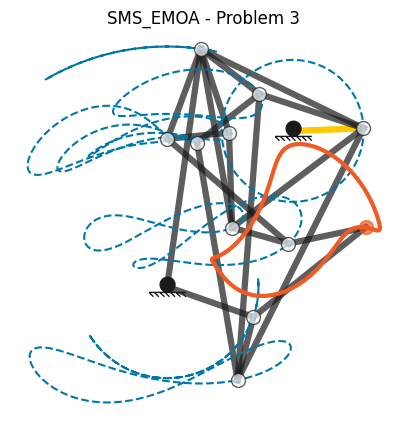

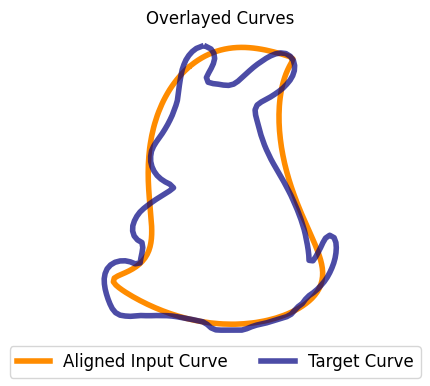

In [11]:
# Only plots of optimized results; rerun this cell without repeating optimization.
if SHOW_FINAL_CURVE:
    visualizer = MechanismVisualizer()
    curve_engine = CurveEngine(resolution=PROBLEM_TOOLS.timesteps, normalize_scale=False)
    for algorithm_name, target_records in selected_records.items():
        for target_index, records in target_records.items():
            if not records:
                print(f'{algorithm_name}, Problem {target_index + 1}: no feasible designs to plot.')
                continue
            best = min(records, key=lambda r: r['F'][0])
            mech = best['mech']
            print(f"{algorithm_name}, Problem {target_index + 1}: "
                  f"distance={best['F'][0]:.6g}, material={best['F'][1]:.6g}, "
                  f"joints={len(mech['x0'])}, links={len(mech['edges'])}")
            fig, ax = plt.subplots(figsize=(5, 5))
            visualizer(mech['x0'], mech['edges'], mech['fixed_joints'], mech['motor'],
                       highlight=mech['target_joint'], ax=ax)
            ax.set_title(f'{algorithm_name} - Problem {target_index + 1}')
            plt.show()
            solutions = np.asarray(PROBLEM_TOOLS.solver(
                [mech['x0']], [mech['edges']], [mech['fixed_joints']], [mech['motor']],
            ))
            traced_curve = solutions[0, mech['target_joint']]
            with jax.disable_jit():
                curve_engine.visualize_comparison(traced_curve, np.asarray(target_curves[target_index]))
            plt.show()
